In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import json
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.model_selection import ParameterGrid
from sklearn.metrics.pairwise import euclidean_distances
from IPython.display import display, Markdown
from kneed import DataGenerator, KneeLocator
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the beatmap object and slider proportions dataset
circle_df = pd.read_csv('dataset.csv')
slider_df = pd.read_csv('dataset_slider.csv')

# Merge the two datasets
id_df = pd.merge(circle_df, slider_df, on=['BeatmapID'], how='left')
# Make a copy of the dataset without the beatmap ID
df = id_df.drop(['BeatmapID'], axis=1)

In [4]:
silhouette_scores = {}
num_solo = {}
distortions = {}
inertias = {}

# Test the K-Means Clustering model with 10 to 4000 clusters
for n_clusters_val in tqdm(range(10, 4001, 10)):
    # Create the K-Means Clustering model with n_clusters_val clusters
    kmeans = KMeans(init='k-means++', n_clusters=n_clusters_val, n_init='auto', random_state=42)
    # Fit the model to the dataset
    kmeans.fit(df)

    # Calculate the silhouette score
    silhouette_scores[n_clusters_val] = metrics.silhouette_score(df, kmeans.labels_)

    # Count the number of clusters that only have one beatmap
    unique, counts = np.unique(kmeans.labels_, return_counts=True)
    unique_counts = dict(zip(unique, counts))
    one_beatmap_clusters = [k for k, v in unique_counts.items() if v == 1]
    num_solo[n_clusters_val] = len(one_beatmap_clusters)

    # Calculate the distortion and inertia
    distortions[n_clusters_val] = sum(np.min(euclidean_distances(df, kmeans.cluster_centers_), axis=1)) / df.shape[0]
    inertias[n_clusters_val] = kmeans.inertia_

100%|██████████| 400/400 [8:27:20<00:00, 76.10s/it]   


In [5]:
# Export the 4 dictionaries to JSON files
with open('silhouette_scores.json', 'w') as f:
    json.dump(silhouette_scores, f)
with open('num_solo.json', 'w') as f:
    json.dump(num_solo, f)
with open('distortions.json', 'w') as f:
    json.dump(distortions, f)
with open('inertias.json', 'w') as f:
    json.dump(inertias, f)

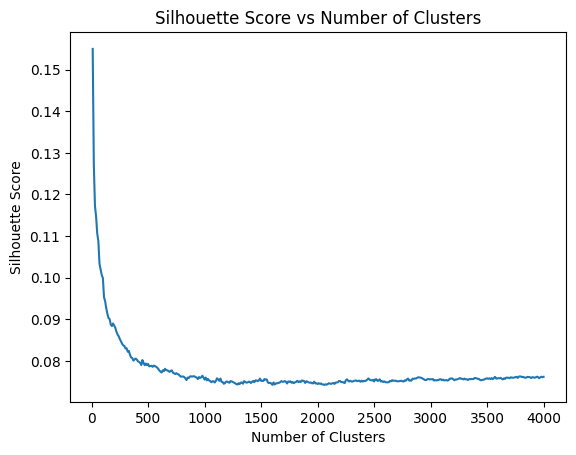

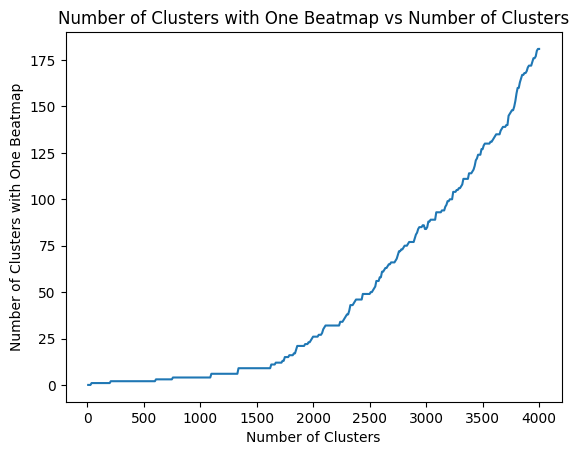

Knee (Inertia): 500
Knee (Distortion): 590


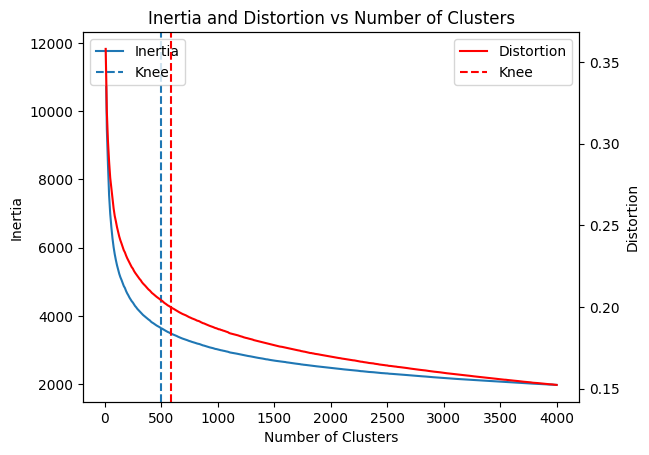

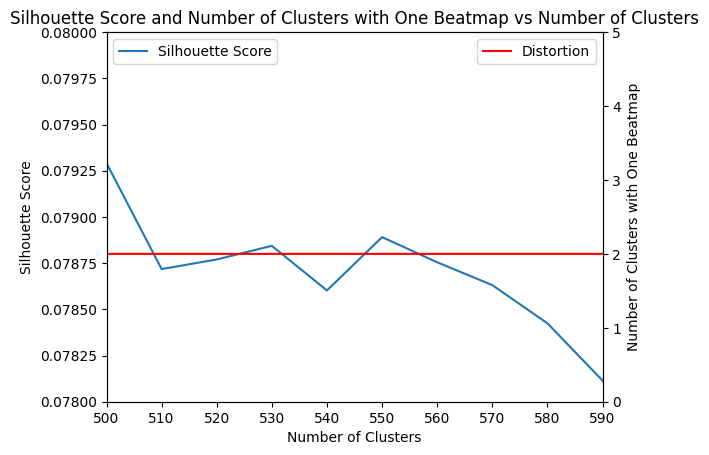

In [81]:
# Plot the silhouette scores
sns.lineplot(x=list(silhouette_scores.keys()), y=list(silhouette_scores.values()))
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.show()

# Plot the number of clusters with only one beatmap
sns.lineplot(x=list(num_solo.keys()), y=list(num_solo.values()))
plt.xlabel('Number of Clusters')
plt.ylabel('Number of Clusters with One Beatmap')
plt.title('Number of Clusters with One Beatmap vs Number of Clusters')
plt.show()

# Find the elbow of the inertia and distortion graphs
kneedle_inert = KneeLocator(
    list(inertias.keys()),
    list(inertias.values()),
    curve='convex',
    direction='decreasing',
)
kneedle_dist = KneeLocator(
    list(distortions.keys()),
    list(distortions.values()),
    curve='convex',
    direction='decreasing',
)
print(f'Knee (Inertia): {round(kneedle_inert.elbow, 3)}')
print(f'Knee (Distortion): {round(kneedle_dist.elbow, 3)}')

# Plot distortion and inertia on the same graph.
sns.lineplot(x=list(inertias.keys()), y=list(inertias.values())).set_ylabel('Inertia')
plt.axvline(x=kneedle_inert.elbow, linestyle='--')
plt.legend(['Inertia', '_', 'Knee'], loc='upper left')
plt.xlabel('Number of Clusters')
ax2 = plt.twinx()
sns.lineplot(x=list(distortions.keys()), y=list(distortions.values()), ax=ax2, color='red').set_ylabel('Distortion')
plt.axvline(x=kneedle_dist.elbow, color='red', linestyle='--')
plt.legend(['Distortion', '_', 'Knee'], loc='upper right')
plt.title('Inertia and Distortion vs Number of Clusters')
plt.show()

sns.lineplot(x=list(silhouette_scores.keys()), y=list(silhouette_scores.values())).set_ylabel('Silhouette Score')
plt.legend(['Silhouette Score'], loc='upper left')
plt.xlim(500, 590)
plt.ylim(0.078, 0.08)
plt.xlabel('Number of Clusters')
ax2 = plt.twinx()
sns.lineplot(x=list(num_solo.keys()), y=list(num_solo.values()), ax=ax2, color='red').set_ylabel('Number of Clusters with One Beatmap')
plt.legend(['Distortion'], loc='upper right')
plt.ylim(0, 5)
plt.title('Silhouette Score and Number of Clusters with One Beatmap vs Number of Clusters')
plt.show()

In [85]:
# Create the K-Means Clustering model with 500 clusters
kmeans = KMeans(init='k-means++', n_clusters=500, n_init='auto', random_state=42)
# Fit the model to the dataset
kmeans.fit(df)

KMeans(n_clusters=500, n_init='auto', random_state=42)

In [84]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)
unique_counts = dict(zip(unique, counts))
one_beatmap_clusters = [k for k, v in unique_counts.items() if v == 1]

for cluster in one_beatmap_clusters:
    # Print out the beatmaps that are in each of these clusters.
    cluster_rows = id_df.loc[kmeans.labels_ == cluster]

    # Create a list of Beatmap IDs in the same cluster
    cluster_beatmaps = cluster_rows['BeatmapID'].tolist()
    print(cluster_beatmaps)

[3109552]
[1502698]


In [101]:
# Beatmap ID to find similar beatmaps for
beatmapID = 2567509

# Find the proportion data for that beatmap
beatmap_row = id_df.loc[id_df['BeatmapID'] == beatmapID]

try:
    # Find the cluster that the beatmap belongs to
    beatmap_cluster = kmeans.predict(beatmap_row.drop(['BeatmapID'], axis=1))

    # Find beatmaps in the dataset that belong to the same cluster
    cluster_rows = id_df.loc[kmeans.labels_ == beatmap_cluster[0]]

    # Create a list of Beatmap IDs in the same cluster
    cluster_beatmaps = cluster_rows['BeatmapID'].tolist()

    sorted_cluster_beatmaps = {}

    # Sort the beatmaps by their euclidean distance from the beatmap we are finding similar beatmaps for
    beatmap1 = id_df.loc[id_df['BeatmapID'] == beatmapID]
    for beatmap in cluster_beatmaps:
        if beatmap == beatmapID:
            continue
        beatmap2 = id_df.loc[id_df['BeatmapID'] == beatmap]
        euclidean_distance = euclidean_distances(beatmap1.drop(['BeatmapID'], axis=1), beatmap2.drop(['BeatmapID'], axis=1))
        sorted_cluster_beatmaps[beatmap] = euclidean_distance[0][0]
    sorted_cluster_beatmaps = dict(sorted(sorted_cluster_beatmaps.items(), key=lambda kv: kv[1]))

    # Open the file containing the beatmap metadata
    with open('../stats.json') as f:
        stats = json.load(f)

        # Print the beatmap we are finding similar beatmaps for
        curr_beatmap_id = stats[f'{beatmapID}']
        display(Markdown(f"Displaying similar beatmaps for [{curr_beatmap_id['artist']} - {curr_beatmap_id['title']} [{curr_beatmap_id['version']}]](http://osu.ppy.sh/b/{beatmapID}):"))
        # Display the amount of beatmaps in the cluster
        display(Markdown(f"{len(sorted_cluster_beatmaps)} similar beatmaps found, only displaying top 10. Lower score is better."))

        # Display the top 10 similar beatmaps
        for i, beatmap in enumerate(sorted_cluster_beatmaps.keys()):
            if i >= 10:
                break
            curr_beatmap_id = stats[f'{beatmap}']
            display(Markdown(f"{i+1}. [{curr_beatmap_id['artist']} - {curr_beatmap_id['title']} [{curr_beatmap_id['version']}]](http://osu.ppy.sh/b/{beatmap}) - {sorted_cluster_beatmaps[beatmap]*100:.2f}"))
# If no similar beatmaps are found, print an error message
except ValueError:
    print("No similar beatmaps found or beatmap not in dataset.")

Displaying similar beatmaps for [REDALiCE - Pekorap Tropical House Remix [Extra]](http://osu.ppy.sh/b/2567509):

173 similar beatmaps found, only displaying top 10. Lower score is better.

1. [Remo Prototype[CV: Hanamori Yumiri] - Sendan Life [Loli's Extra]](http://osu.ppy.sh/b/1390927) - 11.41

2. [Chihiro Yonekura - Koiseyo Otome! [Insane]](http://osu.ppy.sh/b/766319) - 12.37

3. [petit milady - Hakone Hakoiri Musume [Simple]](http://osu.ppy.sh/b/1008851) - 13.98

...

6. [petit milady - Hakone Hakoiri Musume [Extra]](http://osu.ppy.sh/b/882272) - 15.55

7. [JO*STARS ~TOMMY, Coda, JIN~ - JoJo Sono Chi no Kioku~end of THE WORLD~ [STAR PLATINUM]](http://osu.ppy.sh/b/614323) - 15.96

8. [Remo Prototype[CV: Hanamori Yumiri] - Sendan Life [StarR's Extra]](http://osu.ppy.sh/b/979547) - 17.29

9. [TUYU - Doro no Bunzai de Watashi dake no Taisetsu o Ubaouda nante [Shallowness]](http://osu.ppy.sh/b/2590221) - 17.87

10. [UVERworld - ROB THE FRONTIER (TV Size) [FRONTIER]](http://osu.ppy.sh/b/2823539) - 18.89

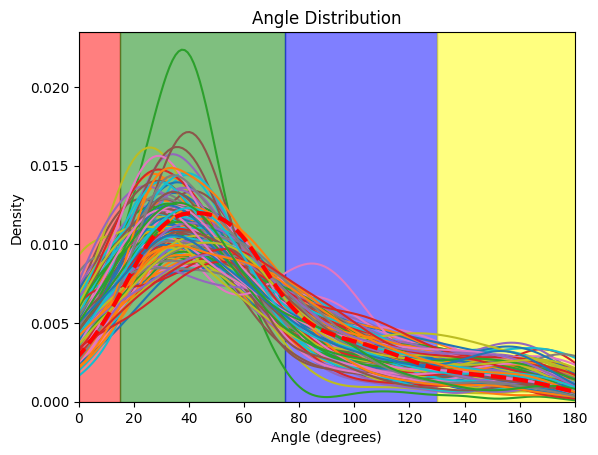

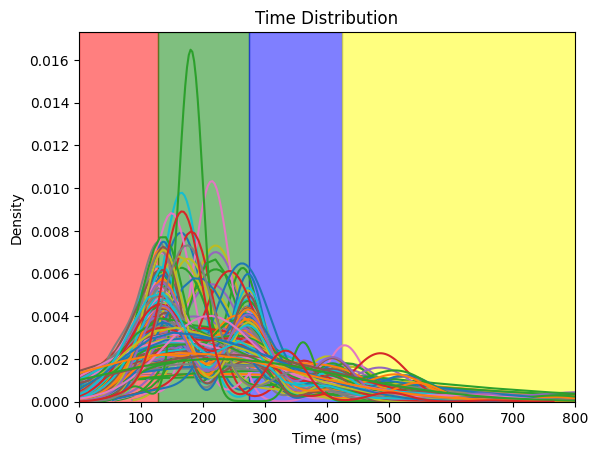

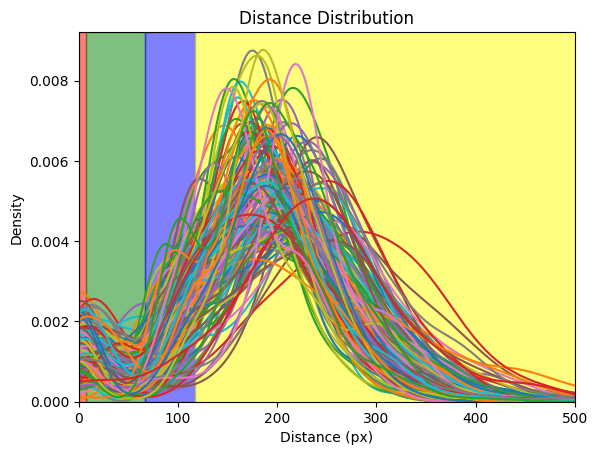

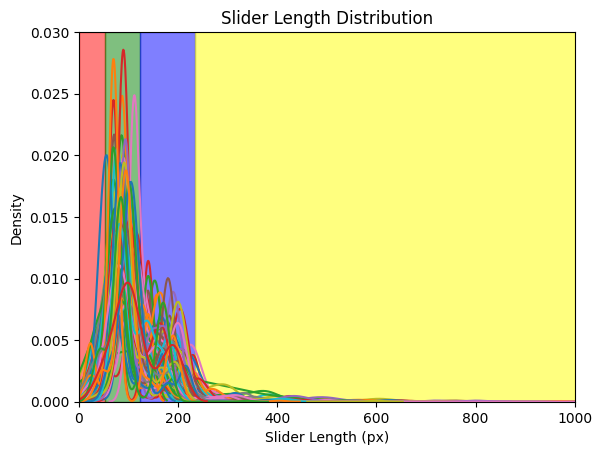

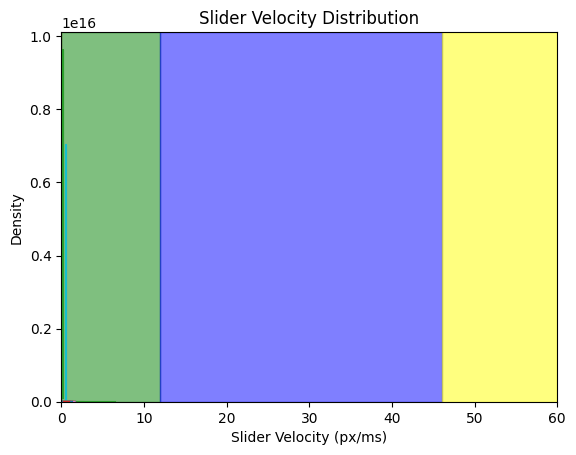

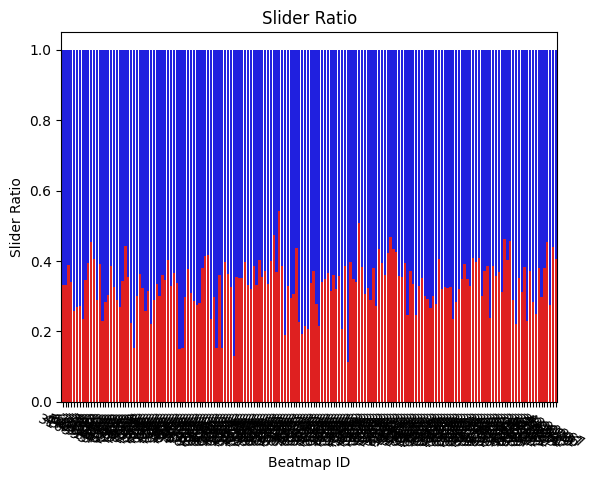

In [111]:
angle_breaks = [15, 75, 130]
time_breaks = [128, 275, 424]
distance_breaks = [7, 67, 117]
angle_lists = []
time_lists = []
distance_lists = []
for beatmap in cluster_beatmaps:
    with open(f"../dists/{beatmap}.dist") as f:
        angles = []
        times = []
        distances = []
        for line in f:
            if not line.strip():
                continue
            line = line.strip().split(',')
            angles.append(float(line[0]))
            times.append(float(line[1]))
            distances.append(float(line[2]))
        angle_lists.append(angles)
        time_lists.append(times)
        distance_lists.append(distances)

og_beatmap_i = None
for i, angle in enumerate(angle_lists):
    if cluster_beatmaps[i] == beatmapID:
        og_beatmap_i = i
        continue
    sns.kdeplot(angle)
sns.kdeplot(angle_lists[og_beatmap_i], linewidth=3, color='red', linestyle='--')
plt.title("Angle Distribution")
plt.xlabel("Angle (degrees)")
plt.ylabel("Density")
# Set the x-axis range to be from 0 to 180.
plt.xlim(0, 180)
plt.axvspan(0, angle_breaks[0], alpha=0.5, color='red')
plt.axvspan(angle_breaks[0], angle_breaks[1], alpha=0.5, color='green')
plt.axvspan(angle_breaks[1], angle_breaks[2], alpha=0.5, color='blue')
plt.axvspan(angle_breaks[2], 180, alpha=0.5, color='yellow')
plt.show()

for time in time_lists:
    sns.kdeplot(time)
plt.title("Time Distribution")
plt.xlabel("Time (ms)")
plt.ylabel("Density")
plt.xlim(0, 800)
plt.axvspan(0, time_breaks[0], alpha=0.5, color='red')
plt.axvspan(time_breaks[0], time_breaks[1], alpha=0.5, color='green')
plt.axvspan(time_breaks[1], time_breaks[2], alpha=0.5, color='blue')
plt.axvspan(time_breaks[2], 800, alpha=0.5, color='yellow')
plt.show()

for distance in distance_lists:
    sns.kdeplot(distance)
plt.title("Distance Distribution")
plt.xlabel("Distance (px)")
plt.ylabel("Density")
plt.xlim(0, 500)
plt.axvspan(0, distance_breaks[0], alpha=0.5, color='red')
plt.axvspan(distance_breaks[0], distance_breaks[1], alpha=0.5, color='green')
plt.axvspan(distance_breaks[1], distance_breaks[2], alpha=0.5, color='blue')
plt.axvspan(distance_breaks[2], 500, alpha=0.5, color='yellow')
plt.show()

slider_length_breaks = [53, 123, 235]
slider_velocity_breaks = [0, 12, 46]
slider_length_lists = []
slider_velocity_lists = []
slider_ratio_list = []
for beatmap in cluster_beatmaps:
    with open(f"../sliders/{beatmap}.sldr") as f:
        slider_lengths = []
        slider_velocities = []
        for line in f:
            if not line.strip():
                continue
            line = line.strip().split(',')
            if len(line) != 2:
                slider_ratio_list.append(float(line[0]))
                continue
            slider_lengths.append(float(line[0]))
            slider_velocities.append(float(line[1]))
        slider_length_lists.append(slider_lengths)
        slider_velocity_lists.append(slider_velocities)

for slider_length in slider_length_lists:
    sns.kdeplot(slider_length)
plt.title("Slider Length Distribution")
plt.xlabel("Slider Length (px)")
plt.ylabel("Density")
plt.xlim(0, 1000)
plt.axvspan(0, slider_length_breaks[0], alpha=0.5, color='red')
plt.axvspan(slider_length_breaks[0], slider_length_breaks[1], alpha=0.5, color='green')
plt.axvspan(slider_length_breaks[1], slider_length_breaks[2], alpha=0.5, color='blue')
plt.axvspan(slider_length_breaks[2], 1000, alpha=0.5, color='yellow')
plt.show()

for slider_velocity in slider_velocity_lists:
    sns.kdeplot(slider_velocity)
plt.title("Slider Velocity Distribution")
plt.xlabel("Slider Velocity (px/ms)")
plt.ylabel("Density")
plt.xlim(0, 60)
plt.axvspan(0, slider_velocity_breaks[0], alpha=0.5, color='red')
plt.axvspan(slider_velocity_breaks[0], slider_velocity_breaks[1], alpha=0.5, color='green')
plt.axvspan(slider_velocity_breaks[1], slider_velocity_breaks[2], alpha=0.5, color='blue')
plt.axvspan(slider_velocity_breaks[2], 60, alpha=0.5, color='yellow')
plt.show()

# Create a bar plot of the slider ratios.
# Make a barplot where the y data is all 1's.
bar1 = sns.barplot(x=cluster_beatmaps, y=[1 for i in range(len(cluster_beatmaps))], color='blue')
bar2 = sns.barplot(x=cluster_beatmaps, y=slider_ratio_list, color='red')
top_bar = mpatches.Patch(color='blue', label='Circle')
bottom_bar = mpatches.Patch(color='red', label='Slider')
plt.title("Slider Ratio")
plt.xlabel("Beatmap ID")
plt.ylabel("Slider Ratio")
# Rotate the x-axis labels by 90 degrees.
plt.xticks(rotation=-25)
plt.show()

In [ ]:
pca_2 = PCA(n_components=2)
pca_2_result = pca_2.fit_transform(df)
print('Explained variation per principal component: {}'.format(pca_2.explained_variance_ratio_))
print('Cumulative variance explained by 2 principal components: {:.2%}'.format(np.sum(pca_2.explained_variance_ratio_)))

# Results from pca.components_
dataset_pca = pd.DataFrame(abs(pca_2.components_), columns=df.columns, index=['PC_1', 'PC_2'])
print('\n\n', dataset_pca)

print("\n*************** Most important features *************************")
print('As per PC 1:\n', (dataset_pca[dataset_pca > 0.3].iloc[0]).dropna())
print('\n\nAs per PC 2:\n', (dataset_pca[dataset_pca > 0.3].iloc[1]).dropna())
print("\n******************************************************************")

In [ ]:
parameters = [3, 7, 15, 38, 77, 155, 775, 1551, 3102, 7755, 15511]

# instantiating ParameterGrid, pass number of clusters as input
parameter_grid = ParameterGrid({'n_clusters': parameters})

best_score = -1
kmeans_model = KMeans(init='k-means++', n_init='auto', random_state=42)
silhouette_scores = []

# evaluation based on silhouette_score
for p in parameter_grid:
    kmeans_model.set_params(**p)    # set current hyper parameter
    kmeans_model.fit(df)          # fit model on wine dataset, this will find clusters based on parameter p

    ss = metrics.silhouette_score(df, kmeans_model.labels_)   # calculate silhouette_score
    silhouette_scores += [ss]       # store all the scores

    print('Parameter:', p, 'Score', ss)

    # check p which has the best score
    if ss > best_score:
        best_score = ss
        best_grid = p

# plotting silhouette score
plt.bar(range(len(silhouette_scores)), list(silhouette_scores), align='center', color='#722f59', width=0.5)
plt.xticks(range(len(silhouette_scores)), list(parameters))
plt.title('Silhouette Score', fontweight='bold')
plt.xlabel('Number of Clusters')
plt.show()